In [1]:
import numpy as np
import json
from neuromancer.system import Node, System
from neuromancer.dynamics import ode, integrators

from SparseDPC.vectorized.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from SparseDPC.vectorized.sindy import CompiledFunctionLibrary, SINDyVectorized
from SparseDPC.vectorized.trainer import SparseTrainer, SparsePolicyBuilder
from SparseDPC.vectorized.data import get_policy_data
from SparseDPC.vectorized.plot import *

import neuromancer.psl as psl
from utils import *

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [4]:
# Ground truth system model
gt_model = psl.nonautonomous.TwoTank()

# Sampling rate
ts = gt_model.params[1]['ts']

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1


## Load Dynamics and Policy Models


In [2]:
import torch
import torch.nn as nn

import torch

run_id = 1
models_dir = f"../results/models/dynamics/run_{run_id}/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/sindy.pt", map_location=device)

# Rebuild library and model skeleton
lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
sindy = SINDyVectorized(
    library=lib,
    n_out=ckpt["model_cfg"]["n_out"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
sindy.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(sindy.active_idx):
    sindy.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
sindy._plan = sindy._recompile_fast_path(device=device)

# Load weights
sindy.load_state_dict(ckpt["state_dict"], strict=True)


/var/folders/7d/4w2xzdbj279fj424x2h2w2xh0000gn/T/ipykernel_46013/41613913.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(models_dir) + "/sindy.pt"

<All keys matched successfully>

In [3]:
import torch
import torch.nn as nn


import torch

run_id = 1
models_dir = f"../results/models/run_{run_id}/SparseDPC/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/policy_sparse.pt", map_location=device)

# Rebuild library and model skeleton
policy_lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
policy_sparse = SINDyVectorized(
    library=policy_lib,
    n_out=ckpt["model_cfg"]["n_out"],
    policy_name=ckpt["model_cfg"]["policy_name"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
policy_sparse.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(policy_sparse.active_idx):
    policy_sparse.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
policy_sparse._plan = policy_sparse._recompile_fast_path(device=device)

# Load weights
policy_sparse.load_state_dict(ckpt["state_dict"], strict=True)


/var/folders/7d/4w2xzdbj279fj424x2h2w2xh0000gn/T/ipykernel_46013/1839147410.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(models_dir) + "/policy_

<All keys matched successfully>

In [5]:
### NEURAL NETWORK (NN) MODELS ###
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations

nn_files = "../results/models/neural/NN-DPC/saved_models"

net_policy = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=[32,32],
                    nonlin=activations['gelu'], min=umin, max=umax)
nn_policy = Node(net_policy, ['xn', 'r'], ['u'], name='neural policy')
nn_policy.load_state_dict(torch.load(nn_files+"/policy_nn.pth", weights_only=True))

<All keys matched successfully>

In [6]:
policy_sparse.pretty_print()

u0 = +1.1509e+00·cos(2·x0) + +1.6259e+00·cos(2·x1) + +4.4735e-01·sin(2·r0) + -2.7049e+00·cos(2·r0)
u1 = -9.9996e-01·cos(2·x0) + +1.0093e+00·cos(2·x1)


In [7]:
sindy.pretty_print()

dx0/dt = +7.9942e-02·u0 + -3.9976e-02·sqrt(x0) + -7.9905e-02·u0*u1
dx1/dt = +3.9981e-02·sqrt(x0) + -3.9980e-02·sqrt(x1) + +7.9943e-02·u0*u1


### 📊 Get data

Gets training, dev, and test datasets using the ground truth model.


In [15]:
from SparseDPC.data.getdata import get_data

torch.manual_seed(0)


nsim = 4000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 2000     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

### Dynamics rollout

In [16]:
# Full-state integration using all fx_models
integrator_x = integrators.RK4(sindy, h=ts)
integrator_node_x = Node(integrator_x, ['xn', 'u'], [f'xn'], name="x_integrator")
dynamics_model_x = System([integrator_node_x])
dynamics_model_x.nsteps = test_data['X'].shape[1]


# Run simulation
test_output = dynamics_model_x(test_data)
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T


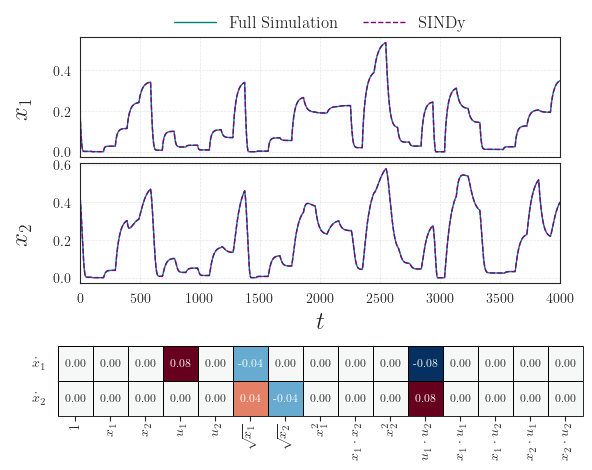

Saved TwoTank_Dynamics.pdf


In [22]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import ticker, patches
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# ========= Simulation outputs =========
pred_traj = test_output['xn'][:, :-1, :].detach().cpu().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().cpu().numpy().reshape(-1, nx).T

# Align lengths
T_pred = pred_traj.shape[1]
true_traj = true_traj[:, :T_pred]
time = np.arange(T_pred)

# ========= Coefficients and labels =========
coef_matrix = sindy.coef.data.detach().cpu().numpy()   # shape (22, 2)
function_names_latex = convert_to_latex(sindy.library.function_names)
n_terms = coef_matrix.shape[0]
n_states = coef_matrix.shape[1]

# ========= Figure parameters =========
FONT_SIZE_COEFS_LABELS = 10
FONT_SIZE_COEFS = 8
CELL_SIZE = 0.3
TS_FIG_WIDTH = 6
TS_FIG_HEIGHT = 2.5

sns.set_style("white")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

# ========= Figure layout =========
heatmap_width = n_terms * CELL_SIZE
heatmap_height = 1.0
fig_height = TS_FIG_HEIGHT + heatmap_height + 0.5
fig = plt.figure(figsize=(TS_FIG_WIDTH, fig_height))

# ========= Time-series plots =========
top_margin = 0.55
gap = 0.015
plot_height = 0.3
plot_width = 0.8
left_margin = (1 - plot_width) / 2

ax0 = fig.add_axes([left_margin, top_margin, plot_width, plot_height])
ax1 = fig.add_axes([left_margin, top_margin - plot_height - gap, plot_width, plot_height])

ax0.plot(time, true_traj[0], color='teal', label='Full Simulation', linewidth=1)
ax0.plot(time, pred_traj[0], color='purple', linestyle='--', linewidth=1, label='SINDy')
ax0.set_ylabel(r"$x_1$", fontsize=18)
ax0.set_xlim([0, len(time)])
ax0.tick_params(axis='y', labelsize=10)

ax0.yaxis.set_major_locator(MultipleLocator(0.2))
ax0.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax0.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

ax1.plot(time, true_traj[1], color='teal', linewidth=1)
ax1.plot(time, pred_traj[1], color='purple', linestyle='--', linewidth=1)
ax1.set_ylabel(r"$x_2$", fontsize=18)
ax1.set_xlabel(r"$t$", fontsize=18)
ax1.set_xlim([0, len(time)])
ax1.tick_params(axis='both', labelsize=10)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

ax0.yaxis.set_label_coords(-0.1, 0.4)
ax1.yaxis.set_label_coords(-0.1, 0.4)


# ========= Coefficient heatmap (2 rows for 2 states) =========
coef_matrix_T = coef_matrix.T  # shape (2, 22)

fx_labels = [rf"$\dot{{x}}_{i+1}$" for i in range(coef_matrix_T.shape[0])]

# Make cells smaller by reducing CELL_SIZE and heatmap height
CELL_SIZE = 0.35   # smaller cell size
heatmap_width = coef_matrix_T.shape[1] * CELL_SIZE
heatmap_height = 0.15 * coef_matrix_T.shape[0]
heatmap_width_figunits = heatmap_width / TS_FIG_WIDTH
heatmap_left = (1 - heatmap_width_figunits) / 2

heatmap_bottom = -0.1     # move this up or down to adjust spacing
heatmap_height = 0.18

ax3 = fig.add_axes([heatmap_left, heatmap_bottom, heatmap_width_figunits, heatmap_height])

sns.heatmap(
    coef_matrix_T,
    annot=True,
    fmt=".2f",                     # show 1 decimal place
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,                # thinner grid lines
    linecolor='black',
    xticklabels=function_names_latex,
    yticklabels=fx_labels,
    cbar=False,
    square=True,                   # uniform square cells
    annot_kws={"size": FONT_SIZE_COEFS},
    ax=ax3
)

# Outline border
rect = patches.Rectangle(
    (0, 0),
    coef_matrix_T.shape[1],
    coef_matrix_T.shape[0],
    linewidth=0.6,
    edgecolor='black',
    facecolor='none',
    clip_on=False,
    zorder=10
)
ax3.add_patch(rect)

# Tick formatting
ax3.tick_params(axis='x', rotation=90, labelsize=FONT_SIZE_COEFS_LABELS, pad=1)
ax3.tick_params(axis='y', rotation=0, labelsize=FONT_SIZE_COEFS_LABELS, pad=5)
ax3.xaxis.tick_bottom()

# ========= Legend =========
handles, labels = ax0.get_legend_handles_labels()
bbox = ax0.get_position()
legend_bottom = bbox.y1 + 0.01
legend_ax = fig.add_axes([bbox.x0, legend_bottom, bbox.width, 0.05])
legend_ax.axis("off")
legend_ax.legend(handles, labels, loc='center', ncol=len(handles),
                 fontsize=12, frameon=False, handlelength=2.5, columnspacing=1.5)

# ========= Save =========
out = "TwoTank_Dynamics.pdf"
fig.savefig(out, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved {out}")


### Policy Evaluation



In [24]:
# White-box ODE model (ground truth)
two_tank = ode.TwoTankParam()
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)
# integrate continuous time ODE# integrate continuous time ODE
gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

SD_SINDy_policy_node = Node(
                lambda xn, r: torch.clamp(policy_sparse(xn, r), umin, umax),
                ['xn', 'r'], ['u'],
                name="policy_combined"
            )


SD_System= copy.deepcopy(System([SD_SINDy_policy_node,
                       gt_integrator_node]))

NN_System= copy.deepcopy(System([nn_policy,
                       gt_integrator_node]))


systems = {
    "SD-DPC": SD_System,
    "NN-DPC":    NN_System,
    # add more if you want them on the plot
}
# Example style map (same color per controller; your function uses it)
style_map = {
    "NN-DPC": ("-", 1.1, 0.5, "darkorange"),
    "MPC": ("-", 1.1, 0.5, "darkgreen"),
    "SD-DPC": ("-", 1.1, 0.94, "royalblue"),
}

In [83]:
import importlib
import utils

importlib.reload(utils)
from utils import *

In [95]:
def combined_controller_and_sparse_policy_heatmap(
    Y_list, U_list,
    controller_labels,
    sparse_policy,                     # single policy object
    fx_policy_labels=(r"$u_1$", r"$u_2$"),
    R=None,
    style_map=None,
    TS_FIG_WIDTH=10.5, TS_FIG_HEIGHT=3.2,
    CELL_SIZE=0.35,                    # slightly wider cells so basis labels breathe
    FONT_SIZE_COEFS=5,
    FONT_SIZE_COEFS_LABELS=11,         # larger tick labels on heatmap
    save_name="CombinedPlot.pdf",
    title=None,
    xmin=None, xmax=None,
    umin=None, umax=None,
    # NEW: tighten label next to heatmap (axes coords)
    heatmap_label_offset_x=-0.08       # move label closer: -0.12 further out, -0.05 closer in
):
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib import ticker, patches
    from matplotlib.lines import Line2D

    # --- Style (same LaTeX look as before) ---
    sns.set_style("whitegrid")
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "text.latex.preamble": r"\usepackage{amsmath}",
    })

    # --- Basis labels (your helper) ---
    function_names_latex = convert_to_latex_policy(
        getattr(sparse_policy.library, "function_names", [])
    )
    print(function_names_latex)
    n_terms = len(function_names_latex)

    # --- Coeffs -> (n_outputs, n_terms) ---
    coef = sparse_policy.coef.detach().cpu().numpy()
    if coef.shape[0] == n_terms:
        coef_matrix = coef.T
    elif coef.shape[1] == n_terms:
        coef_matrix = coef
    else:
        raise ValueError(f"Unexpected coef shape {coef.shape} vs {n_terms} terms.")
    ytick = list(fx_policy_labels)[:coef_matrix.shape[0]]

    # --- Layout sizing (scaled up to a clean stacked look) ---
    heatmap_width = n_terms * CELL_SIZE
    heatmap_height = 0.26               # vertical height of heatmap band
    gap_between_blocks = 0.5           # global slack between top stack and heatmap
    fig_height = TS_FIG_HEIGHT + heatmap_height + gap_between_blocks + 0.40
    fig = plt.figure(figsize=(TS_FIG_WIDTH, fig_height))

    # normalized width of the heatmap in figure coordinates, centered
    heatmap_width_figunits = heatmap_width / TS_FIG_WIDTH
    heatmap_width_figunits = min(0.82, heatmap_width_figunits)   # avoid going edge to edge
    heatmap_left = (1.0 - heatmap_width_figunits) / 2.0

    nsteps = Y_list[0].shape[0] - 1
    t = np.arange(nsteps + 1)

    # --- Top panels layout: stacked states and controls, nicely spaced ---
    top_margin = 0.68        # y of bottom of x-plot (slightly below legend)
    plot_height = 0.4       # height of each time-series panel
    plot_width = 0.7        # wide and centered horizontally
    left_margin = (1.0 - plot_width) / 2.0
    vertical_gap = 0.16      # gap between x and u plots

    # States on top
    ax_x = fig.add_axes([left_margin, top_margin, plot_width, plot_height])

    # Controls below
    ax_u = fig.add_axes([
        left_margin,
        top_margin - plot_height - vertical_gap,
        plot_width,
        plot_height
    ])

    # Legend strip centered above both
    leg_height = 0.06
    leg_bottom = top_margin + plot_height + 0.03
    leg_ax = fig.add_axes([
        left_margin,
        leg_bottom,
        plot_width,
        leg_height
    ])
    leg_ax.axis("off")

    handles = []

    if R is not None:
        h_ref, = ax_x.plot(t, R[:, 0], '--', lw=1.0, color='red', label="Ref")
        handles.append(h_ref)

    for i, lbl in enumerate(controller_labels):
        ls, lw, a, col = style_map[lbl]
        ax_x.plot(t, Y_list[i][:, 0], linestyle=ls, linewidth=lw, alpha=a, color=col)
        ax_x.plot(t, Y_list[i][:, 1], linestyle=(0, (3, 1, 1, 1, 1, 1)), linewidth=lw, alpha=a, color=col)
        ax_u.plot(t[:-1], U_list[i][:, 0], linestyle=ls, linewidth=lw, alpha=a, color=col)
        ax_u.plot(t[:-1], U_list[i][:, 1], linestyle=(0, (3, 1, 1, 1, 1, 1)), linewidth=lw, alpha=a, color=col)

        handles.append(Line2D([0], [0], color=col, label=lbl, linewidth=1.6, linestyle=ls))

    leg_ax.legend(
        handles,
        [h.get_label() for h in handles],
        loc='center',
        ncol=len(handles),
        fontsize=12,
        frameon=False,
        handlelength=2.6,
        columnspacing=1.4
    )

    # --- Axis cosmetics for top plots ---
    if umin is not None:
        ax_u.hlines(umin, 0, nsteps, color='black', lw=0.8, ls='--')
    if umax is not None:
        ax_u.hlines(umax, 0, nsteps, color='black', lw=0.8, ls='--')

    ax_x.set_ylabel(r"$x$", fontsize=18, rotation=0)
    ax_x.set_xlabel(r"$t$", fontsize=18, labelpad=8)
    ax_u.set_ylabel(r"$u$", fontsize=18, rotation=0)
    ax_u.set_xlabel(r"$t$", fontsize=18, labelpad=8)

    ax_x.set_xlim(0, nsteps)
    ax_u.set_xlim(0, nsteps)
    ax_x.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax_u.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax_x.tick_params(axis='both', labelsize=12)
    ax_u.tick_params(axis='both', labelsize=12)
    ax_x.grid(True, ls='--', lw=0.6, alpha=0.5)
    ax_u.grid(True, ls='--', lw=0.6, alpha=0.5)

    # Fix axis label centering
    ax_x.yaxis.set_label_coords(-0.1, 0.4)
    ax_u.yaxis.set_label_coords(-0.1, 0.4)

    # --- Bottom: heatmap (centered), with comfortable gap from u-plot ---
    # place heatmap so that there is a visible but tight gap under ax_u
    heatmap_bottom = -0.28
    ax_h = fig.add_axes([heatmap_left, heatmap_bottom, heatmap_width_figunits, heatmap_height])

    vlim = 5
    hm = sns.heatmap(
        coef_matrix,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0, vmin=-vlim, vmax=vlim,
        square=True,
        linewidths=0.7, linecolor='black',
        xticklabels=function_names_latex,
        yticklabels=ytick,
        cbar=False,
        ax=ax_h,
        annot_kws={"size": 8}
    )
    ax_h.grid(False)
    ax_h.tick_params(axis='x', rotation=90, labelsize=FONT_SIZE_COEFS_LABELS, pad=2)
    ax_h.tick_params(axis='y', rotation=0, labelsize=FONT_SIZE_COEFS_LABELS, pad=6)

    # optional: nudge y-axis label if you later add one, using heatmap_label_offset_x
    # for example:
    # ax_h.yaxis.set_label_coords(heatmap_label_offset_x, 0.5)

    # border
    ax_h.add_patch(patches.Rectangle(
        (0, 0),
        coef_matrix.shape[1],
        coef_matrix.shape[0],
        linewidth=0.9,
        edgecolor='black',
        facecolor='none',
        clip_on=False,
        zorder=10
    ))

    # right-side colorbar
    pos = ax_h.get_position()
    cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.016, pos.height])
    cb = plt.colorbar(hm.collections[0], cax=cax)
    cb.ax.tick_params(labelsize=10)

    if title is not None:
        fig.suptitle(title, fontsize=18, fontweight='bold', y=0.99)

    if save_name:
        fig.savefig(save_name, format=save_name.split('.')[-1], bbox_inches="tight")

    plt.show()


In [88]:
N=50
nsim= 750
step_length = 150

Y_list, U_list, controller_labels, R, losses = run_multi_seed_rollouts(
    systems=systems,
    nsteps=nsim,
    nx=nx, nu=nu, nref=nref,
    xmin=xmin, xmax=xmax, umin=umin, umax=umax,
    device=device,
    n_seeds=1,
    step_length=step_length,
    seed0=8,
    include_mpc=True,
    mpc_fn=mpc_solve_adaptive_horizon,
    mpc_kwargs=dict(two_tank=gt_model, nsim=nsim, N_max=N, N_min=2, step_length=step_length, Ru=0.0, Rdu=0.01)
)


In [89]:
losses

[0.007569423411041498, 0.007751066237688065, 0.005911651067435741]

['$x_{1}$', '$x_{2}$', '$r$', '$\\sqrt{x_{1}}$', '$\\sqrt{x_{2}}$', '$x_{1}^{2}$', '$x_{1} \\cdot x_{2}$', '$x_{2}^{2}$', '$x_{1} \\cdot r$', '$x_{2} \\cdot r$', '$\\sin(1·x_{1})$', '$\\sin(2·x_{1})$', '$\\sin(1·x_{2})$', '$\\sin(2·x_{2})$', '$\\cos(1·x_{1})$', '$\\cos(2·x_{1})$', '$\\cos(1·x_{2})$', '$\\cos(2·x_{2})$', '$\\sin(1·r)$', '$\\sin(2·r)$', '$\\cos(1·r)$', '$\\cos(2·r)$']


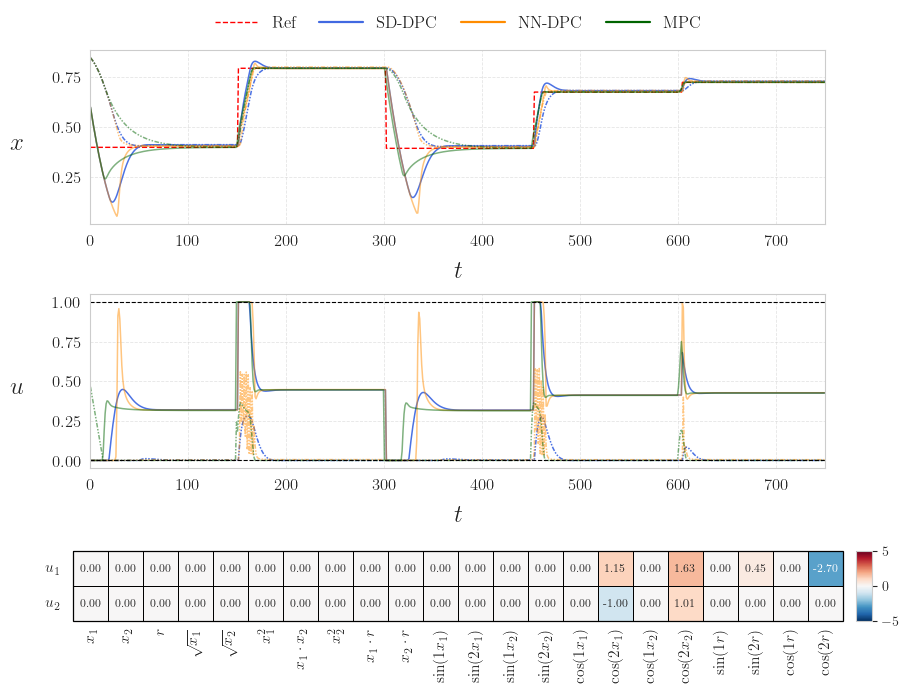

In [96]:
combined_controller_and_sparse_policy_heatmap(
    Y_list, U_list,
    controller_labels,
    sparse_policy=policy_sparse,
    fx_policy_labels=[r"$u_1$", r"$u_2$"],
    R=R,
    style_map=style_map,
    save_name="TwoTank_Control_Traj_Coefs.pdf",
    title="",
    umin=0, umax=1
)
